In [3]:
import torch
import numpy as np
from face_score import FACEScorer
import matplotlib.pyplot as plt

In [4]:
fft_args = {
    'method': 'periodogram'
}

In [5]:
face_scorer = FACEScorer(model_path='/Users/xy/models/gpt2-xl',
                         device='mps', fft_args=fft_args)

face_scorer.fft_processor.print_fft_args()

FFTProcessor: method=periodogram, preprocess=none, value=norm, require_sid=True


In [6]:
nll_file = 'sample/sample_nll_bbc_gemma2-2b_llama3-8b.txt'
n_lines = 1
nlls = []
with open(nll_file, 'r') as f:
    for i, line in enumerate(f):
        if i == n_lines:
            break
        nll = np.array(line.split(), dtype=np.float32)
        nlls.append(nll)
print(nlls)

[array([7.5051e+00, 7.3118e+00, 7.1159e+00, ..., 4.6000e-03, 9.7000e-03,
       3.0000e-03], dtype=float32)]


In [7]:
x = nlls[0]
X = face_scorer.nll_to_spectrum([x])
print(X[0][0][:10], X[1][0][:10])

[2.3283065e-13 1.8522478e+02 6.2645535e+01 1.3044460e+02 1.5032140e+01
 5.8455378e-01 8.1625128e+00 4.3179550e+00 1.6623363e+01 1.1438235e+01] [0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009]


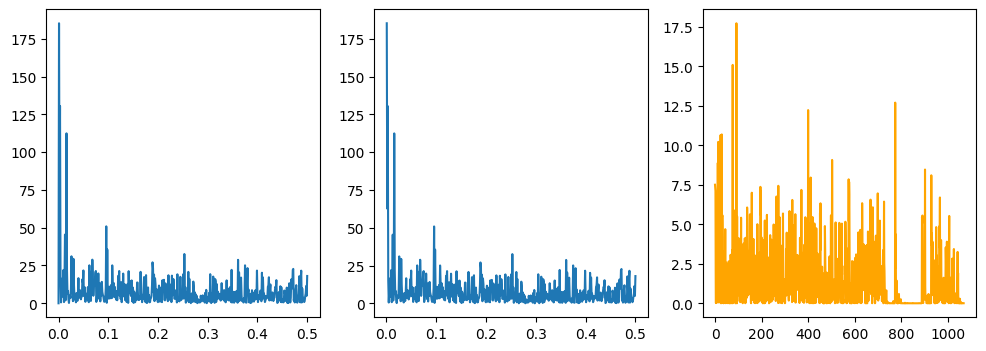

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].plot(X[1][0][:], X[0][0][:])
ax[1].plot(X[1][0][1:], X[0][0][1:])
ax[2].plot(np.arange(len(x)), x, color='orange')

Text(0.5, 1.0, 'periodogram + permuted')

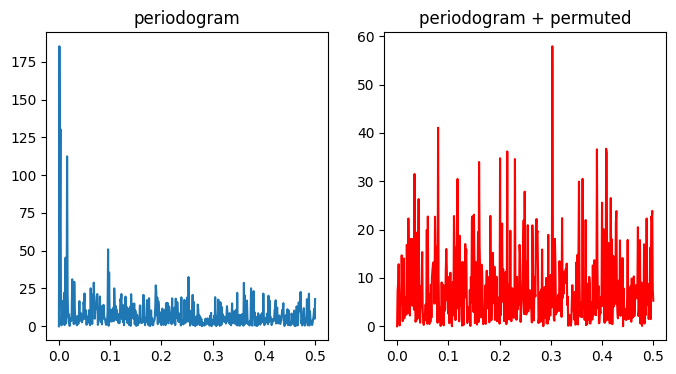

In [9]:
# get permutation of x

x_perm = np.random.permutation(x)

fig, ax = plt.subplots(1, 2, figsize=(8,4))

X = face_scorer.nll_to_spectrum([x])
X_perm = face_scorer.nll_to_spectrum([x_perm])

ax[0].plot(X[1][0][:], X[0][0][:])
ax[1].plot(X_perm[1][0][:], X_perm[0][0][:], color='red')
ax[0].set_title('periodogram')
ax[1].set_title('periodogram + permuted')


In [10]:
# find the period with max power in periodogram

def find_max_power_freq(power: np.ndarray, freq: np.ndarray):
    assert power.shape == freq.shape
    max_power = np.max(power)
    max_freq = freq[np.argmax(power)]
    return max_power, max_freq

In [11]:
print(X[0][0].shape, X[1][0].shape)

max_power, max_freq = find_max_power_freq(X[0][0], X[1][0])
print(max_power, max_freq)

(501,) (501,)
185.22478 0.001


In [12]:
np.percentile(X[0][0], 99)

45.44429016113281

In [13]:
# Raw fft
face_scorer2 = FACEScorer(model_path='/Users/xy/models/gpt2-xl',
                         device='mps')

face_scorer2.fft_processor.print_fft_args()

FFTProcessor: method=fft, preprocess=none, value=norm, require_sid=True


Text(0.5, 1.0, 'fft + permuted (zero excl)')

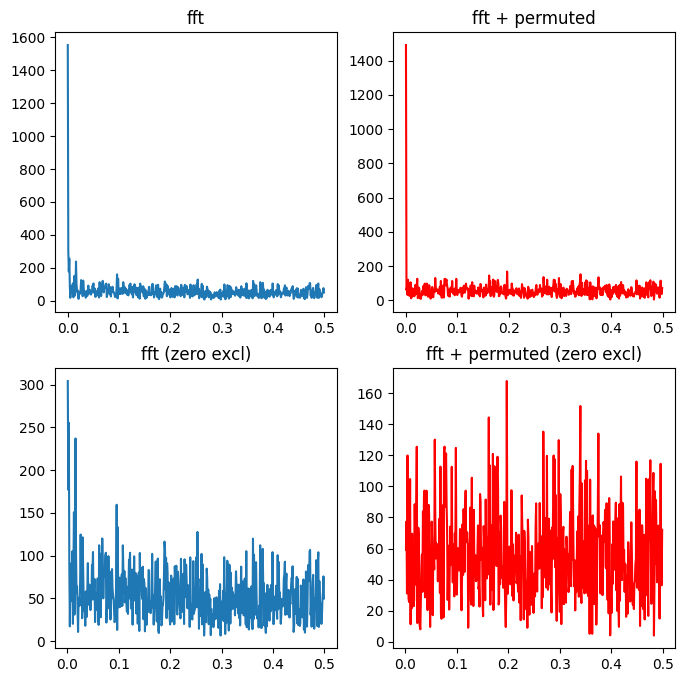

In [14]:
x_perm = np.random.permutation(x)

fig, ax = plt.subplots(2, 2, figsize=(8,8))

X = face_scorer2.nll_to_spectrum([x])
X_perm = face_scorer2.nll_to_spectrum([x_perm])

ax[0][0].plot(X[1][0][:], X[0][0][:])
ax[0][1].plot(X_perm[1][0][:], X_perm[0][0][:], color='red')

ax[0][0].set_title('fft')
ax[0][1].set_title('fft + permuted')

ax[1][0].plot(X[1][0][1:], X[0][0][1:])
ax[1][1].plot(X_perm[1][0][1:], X_perm[0][0][1:], color='red')

ax[1][0].set_title('fft (zero excl)')
ax[1][1].set_title('fft + permuted (zero excl)')

In [177]:
# Implement get_period_hints(q)

def get_period_hints(q: np.ndarray, spectrum_extractor, percentile=90, k=100, debug=False):
    max_powers = []
    periods = []

    for _ in range(k):
        q_perm = np.random.permutation(q)
        power, freq = spectrum_extractor(q_perm)
        max_power, _ = find_max_power_freq(power, freq)
        max_powers.append(max_power)
    
    power_threshold = np.percentile(max_powers, percentile)
    if debug:
        print('power_threshold:', power_threshold)

    power, freq = spectrum_extractor(q)
    for i in range(len(power)):
        if power[i] > power_threshold:
            periods.append(1 / freq[i])
    if debug:
        print(f'periods before pruning: {periods}')
    
    periods_pruned = []
    for p in periods:
        if p < len(q) /2 and p > 2:
            periods_pruned.append(p)
    
    return periods_pruned

In [178]:

def construct_spec_extr(face_scorer, exclude_zero=True):
    def spec_extr(x):
        X = face_scorer.nll_to_spectrum([x])
        if exclude_zero and X[1][0][0] == 0:
            power, freq = X[0][0][1:], X[1][0][1:]
        else:
            power, freq = X[0][0], X[1][0]
        return power, freq
    return spec_extr


sp_extr1 = construct_spec_extr(face_scorer)
sp_extr2 = construct_spec_extr(face_scorer2)

In [179]:
periods = get_period_hints(x, spectrum_extractor=sp_extr1)
print(periods)

[500.0, 333.3333333333333, 62.5]


In [180]:
periods = get_period_hints(x, spectrum_extractor=sp_extr2)
print(periods)

[333.3333333333333, 62.5]


In [181]:
# Check how many lines return more than 0 periods

nll_file = 'sample/sample_nll_bbc_gemma2-2b_llama3-8b.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
print(f'{count} lines return more than 0 periods')

sample/sample_nll_bbc_gemma2-2b_llama3-8b.txt
150 lines read
61 lines return more than 0 periods


In [182]:
nll_file = 'sample/sample_nll_bbc_gemma2-2b_out.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
print(f'{count} lines return more than 0 periods')

sample/sample_nll_bbc_gemma2-2b_out.txt
150 lines read
45 lines return more than 0 periods


In [183]:
nll_file = 'sample/sample_nll_bbc_gemma2-2b_pythia-410m.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
print(f'{count} lines return more than 0 periods')

sample/sample_nll_bbc_gemma2-2b_pythia-410m.txt
150 lines read
39 lines return more than 0 periods


#### writing, xsum, pubmed

In [184]:
nll_file = 'sample/writing_gpt-4.original.bigram.nll.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
all_periods = []
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
        all_periods.extend(periods)
print(f'{count} lines return more than 0 periods')
print(f'average period: {np.mean(all_periods)}')
# print(all_periods)

sample/writing_gpt-4.original.bigram.nll.txt
150 lines read
21 lines return more than 0 periods
average period: 5.538397224073557


In [185]:
nll_file = 'sample/writing_gpt-4.sampled.bigram.nll.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
all_periods = []
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
        all_periods.extend(periods)
print(f'{count} lines return more than 0 periods')
print(f'average period: {np.mean(all_periods)}')
# print(all_periods)

sample/writing_gpt-4.sampled.bigram.nll.txt
150 lines read
32 lines return more than 0 periods
average period: 2.7452316718686975


In [186]:
nll_file = 'sample/xsum_gpt-4.original.bigram.nll.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
all_periods = []
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
        all_periods.extend(periods)
print(f'{count} lines return more than 0 periods')
print(f'average period: {np.mean(all_periods)}')
# print(all_periods)

sample/xsum_gpt-4.original.bigram.nll.txt
150 lines read
24 lines return more than 0 periods
average period: 3.200986216100436


In [187]:
nll_file = 'sample/xsum_gpt-4.sampled.bigram.nll.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
all_periods = []
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
        all_periods.extend(periods)
print(f'{count} lines return more than 0 periods')
print(f'average period: {np.mean(all_periods)}')
# print(all_periods)

sample/xsum_gpt-4.sampled.bigram.nll.txt
150 lines read
31 lines return more than 0 periods
average period: 2.829441446903261


In [188]:
nll_file = 'sample/pubmed_gpt-4.original.bigram.nll.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
all_periods = []
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
        all_periods.extend(periods)
print(f'{count} lines return more than 0 periods')
print(f'average period: {np.mean(all_periods)}')
# print(all_periods)

sample/pubmed_gpt-4.original.bigram.nll.txt
150 lines read
18 lines return more than 0 periods
average period: 2.885752176790824


In [189]:
nll_file = 'sample/pubmed_gpt-4.sampled.bigram.nll.txt'
nlls = face_scorer.fft_processor.load_nll(nll_file)

print(nll_file)
print(f'{len(nlls)} lines read')

count = 0
all_periods = []
for q in nlls:
    periods = get_period_hints(q, spectrum_extractor=sp_extr1)
    if len(periods) > 0:
        count += 1
        all_periods.extend(periods)
print(f'{count} lines return more than 0 periods')
print(f'average period: {np.mean(all_periods)}')
# print(all_periods)

sample/pubmed_gpt-4.sampled.bigram.nll.txt
150 lines read
30 lines return more than 0 periods
average period: 2.5026680379587423


Overall, human is less periodical than model